In [ ]:
from src.run_app import *
from src.prepare_gam import *
from src.utils import *
from gam_rs_utils.binarize_dataset import binarize_dataset
from gam_rs_utils.utils import *
from FasterRisk.src.fasterrisk import fasterrisk
from time import time
import pickle

dataset_settings = {
    'bank': {
        'starting_gap_tolerance': 0.0015,
        'gap_tolerance_interval': 0.0015,
        'num_estimators': 50,
    },
    'compas': {
        'starting_gap_tolerance': 0.0005,
        'gap_tolerance_interval': 0.0005,
        'num_estimators': 50,
    },
    'diabetes': {
        'starting_gap_tolerance': 0.001,
        'gap_tolerance_interval': 0.001,
        'num_estimators': 200,
    },
    # 'heloc_original': { # not used
    #     'starting_gap_tolerance': 0.001,
    #     'num_estimators': 50,
    # },
    # 'hiv': { # not used
    #     'gap_tolerance': 0.001,
    #     'starting_num_estimators': 25,
    # },
    'netherlands': {
        'starting_gap_tolerance': 0.0005,
        'gap_tolerance_interval': 0.0005,
        'num_estimators': 50,
    },
    'spambase': {
        'starting_gap_tolerance': 0.003,
        'gap_tolerance_interval': 0.0005,
        'num_estimators': 50,
    },
}

tries = 6
results = []
for dataset_name, settings in dataset_settings.items():
    num_estimators = settings["num_estimators"]

    path = 'datasets/{}.csv'.format(dataset_name)
    dataset = pd.read_csv(path)
    print(f"Dataset: {dataset_name}")
    print(f"shape: {dataset.shape}")

    df, thresholds, header, threshold_guess_time = binarize_dataset(dataset, num_estimators)
    X, y = df.iloc[:, :-1], df.iloc[:, -1]

    header = list(X.columns)
    header = pd.Index(["intercept"] + header)
    header = header.astype("object")

    X_one_hot, y = utils.get_X_y(X, y)

    for i in range(tries):
        gap_tolerance = settings['starting_gap_tolerance'] + i * settings['gap_tolerance_interval']

        start = time()
        rs = fasterrisk.RiskScoreOptimizer(X_one_hot, y, k=10, lb=-100, ub=100, gap_tolerance=gap_tolerance, select_top_m=-1)
        rs.optimize_with_swaps(swaps=3, fanout_decay=1, feature_selection="top")
        end = time()

        results.append((dataset_name, len(header), gap_tolerance,  end - start,  rs.sparseDiversePool_betas, rs.sparseDiversePool_beta0))
        print(f"\t{gap_tolerance} tolerance, {rs.sparseDiversePool_betas.shape[0]} solutions, {end - start:.2f} seconds")

        if end - start > 120:
            print("Last optimization took more than 120 seconds, stopping further tries.")
            break

with open("results/tolerance.pkl", "wb") as f:
    pickle.dump(results, f)

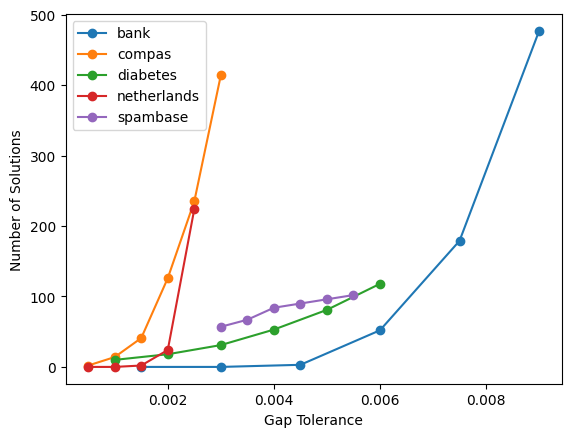

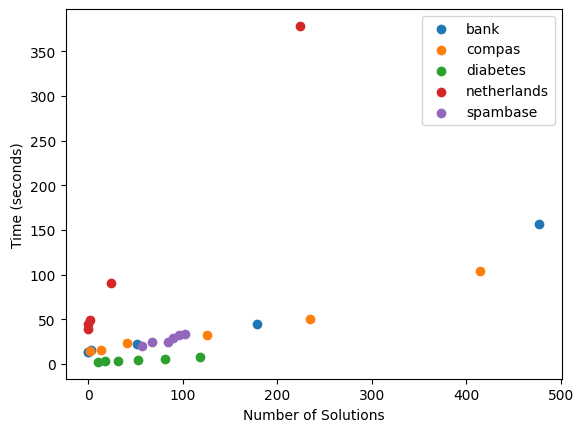

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import pickle

with open("results/tolerance.pkl", "rb") as f:
    results = pickle.load(f)

results = pd.DataFrame(results, columns=["dataset", "num_features", "gap_tolerance", "time", "betas", "beta0"])

fig, ax = plt.subplots()
for dataset_name, data_group in results.groupby("dataset"):
    tolerances = data_group["gap_tolerance"].to_list()
    num_solutions = data_group["betas"].apply(lambda x: x.shape[0])

    ax.plot(tolerances, num_solutions, label=dataset_name, marker="o")
ax.set_xlabel("Gap Tolerance")
ax.set_ylabel("Number of Solutions")
ax.legend()
plt.show()

fig, ax = plt.subplots()
for dataset_name, data_group in results.groupby("dataset"):
    tolerances = data_group["betas"].apply(lambda x: x.shape[0])
    num_solutions = data_group["time"].to_list()

    ax.scatter(tolerances, num_solutions, label=dataset_name, marker="o")
ax.set_xlabel("Number of Solutions")
ax.set_ylabel("Time (seconds)")
ax.legend()
plt.show()